The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[*********************100%***********************]  1 of 1 completed


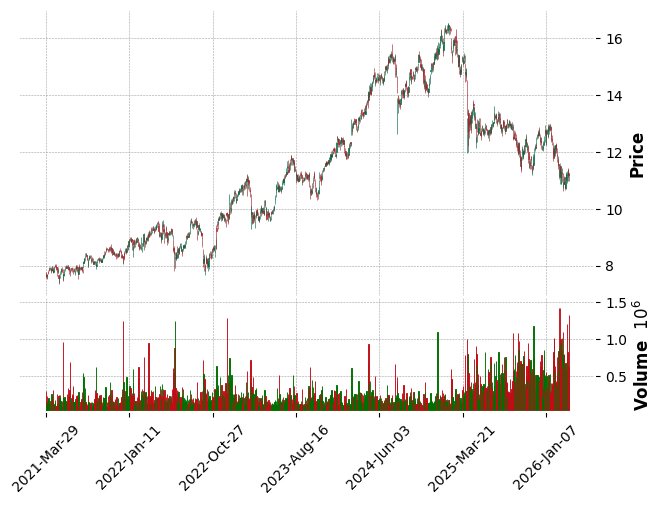

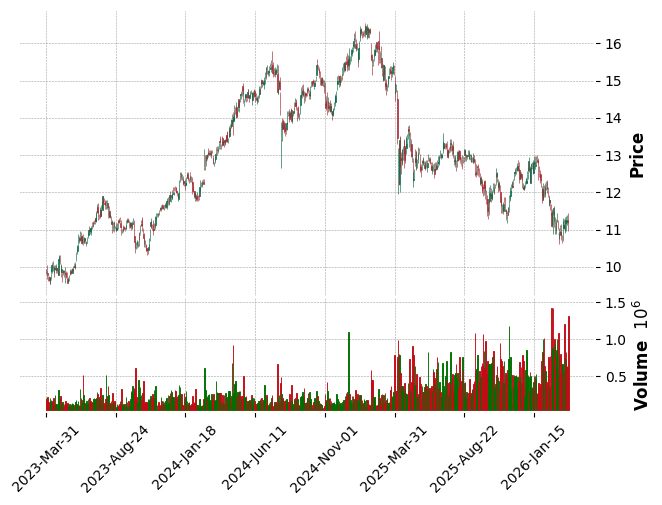

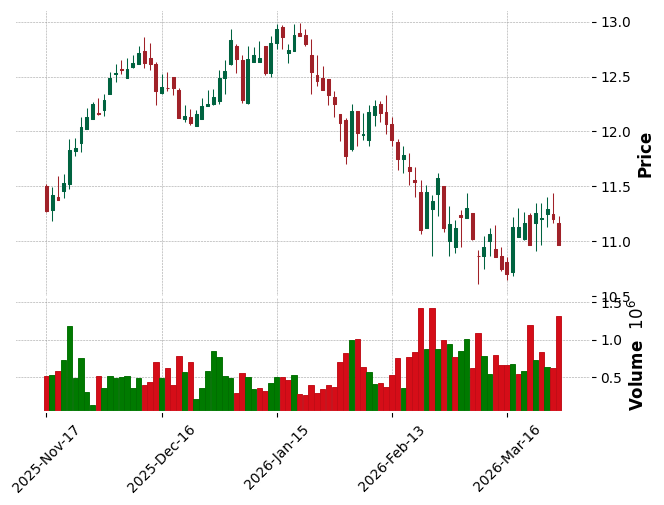

In [16]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [17]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


105.43454545454546


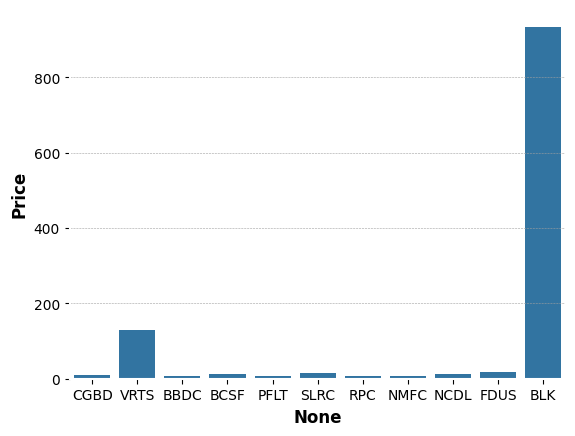

In [18]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [19]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [20]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [21]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bullish (Net Buy): 14,893 shares


In [22]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-13 05:45:33
JP Morgan Maintains Neutral on Carlyle Secured Lending, Lowers Price Target to $10
JP Morgan  analyst Richard Shane   maintains Carlyle Secured Lending (NASDAQ:CGBD) with a Neutral and lowers the price target from $12 to $10.
https://finnhub.io/api/news?id=8c75c5730649c700caf69bbd4544c854a137fd94838727e50bab41dcd85517de

2026-03-07 02:15:00
3 Things That Make You Delusional About BDCs

https://finnhub.io/api/news?id=5a1a338acc5009c4a127c24329d0bad1a3806af365c26e852455b6087aca240f

2026-03-06 01:30:00
Carlyle Secured Lending: I Believe The Dividend Has A +50% Chance Of Being Cut In 2026

https://finnhub.io/api/news?id=80e391b38fb8da0cdff239c39b3febadad9bbd5cd3da9657ce00fb4db0ffee2a

2026-03-04 22:57:21
Buy Any Of March's 5 Ideal 'Safer' Dividend Power Dogs
Dividend Powerâs March 2026 list highlights 35 high-yield, low-priced financial stocks, with five 'safer' picks showing free cash flow yields above dividend...
https://finnhub.io/api/news?id=4b76c8a8341b57814a527

Average Weighted EPS: 0.3439
Lower Standard Deviation: -0.11062612160590662
Upper Standard Deviation: 0.7984261216059065
Total Debt/Total Equity: 1.3117


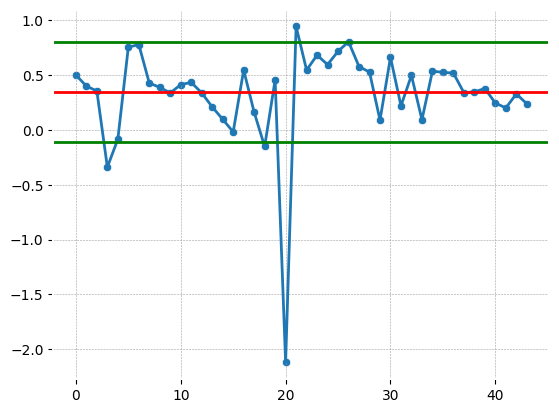

In [23]:
inflect = Fun.get_inflections()

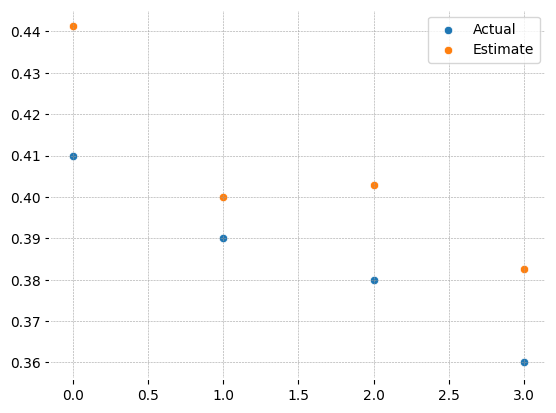

In [24]:
surprise = Fun.eps_surprise()

2021-12-31            NaN
2022-12-31    94673000.00
2023-12-31   101087000.00
2024-12-31    99276000.00
2025-12-31    80987000.00
Name: Total Revenue, dtype: float64
Revenue: [        nan 9.46730e+07 1.01087e+08 9.92760e+07 8.09870e+07]


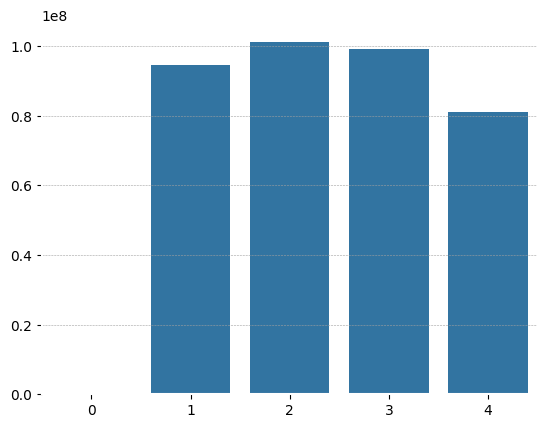

In [25]:
revenue = Fun.revenue_growth()

In [27]:
dcf = Fun.calculate_dcf()

--- Profitability Analysis: CGBD ---

Annual Net Income History:
2021-12-31           NaN
2022-12-31   85637000.00
2023-12-31   92280000.00
2024-12-31   88978000.00
2025-12-31   69972000.00
Name: Net Income, dtype: float64

Last 4 Quarters Net Income:
2025-03-31   14054000.00
2025-06-30   14630000.00
2025-09-30   23903000.00
2025-12-31   17385000.00
Name: Net Income, dtype: float64


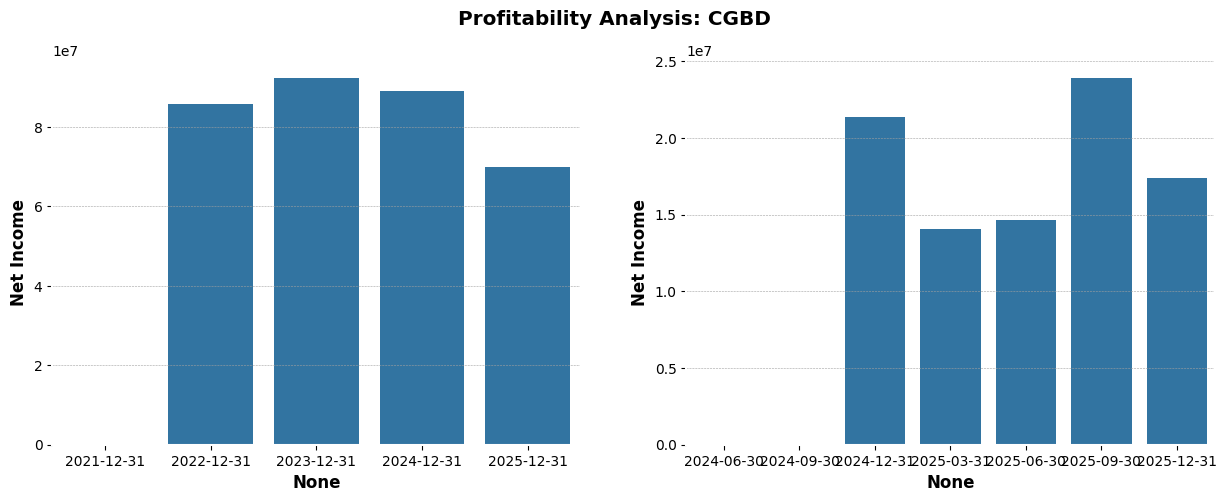

In [30]:
a,q = Fun.check_profitability()